In [ ]:
!pip install qiskit qiskit-aer pylatexenc matplotlib -q

import os
os.kill(os.getpid(), 9)

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import numpy as np

In [32]:
from posixpath import defpath
class GroverAlgorithm:
    """
    A Grover's algorithm class for quantum search.
    It includes methods for the oracle, diffuser  and building the complete circuit.
    """

    def __init__(self, num_qubits: int, oracle_function):
        self.num_qubits = num_qubits
        self.oracle_function = oracle_function  # Placeholder for the oracle function
        self.qc = QuantumCircuit(num_qubits, num_qubits) # Initialize quantum circuit
        self.total_iterations = 0

    def _diffuser(self):
        """Applies the Grover's diffuser operator to amplify the marked state."""
        self.qc.barrier(label="diffuser_start")
        self.qc.h(range(self.num_qubits))
        self.qc.x(range(self.num_qubits))

        control = list(range(self.num_qubits - 1))
        target = self.num_qubits - 1
        self.qc.mcp(np.pi, control, target)

        self.qc.x(range(self.num_qubits))
        self.qc.h(range(self.num_qubits))
        self.qc.barrier(label="diffuser_end")

    def build_circuit(self) -> QuantumCircuit:
        """
        Constructs the full Grover's quantum circuit.
        Initializes qubits, applies oracle and diffuser iteratively, and adds measurements.
        """
        # Initialize qubits in a uniform superposition
        self.qc.h(range(self.num_qubits))

        # Calculate optimal iterations for a single marked state
        self.total_iterations = np.round(np.pi/4 * np.sqrt(2**self.num_qubits)).astype(int)
        print(f"Number of Grover iterations: {self.total_iterations}")

        # Apply Grover iterations (oracle + diffuser)
        for _ in range(self.total_iterations):
            self.oracle_function(self.qc, self.num_qubits)
            self._diffuser()

        # Measure all qubits
        self.qc.measure(range(self.num_qubits), range(self.num_qubits))
        return self.qc

Number of Grover iterations: 2


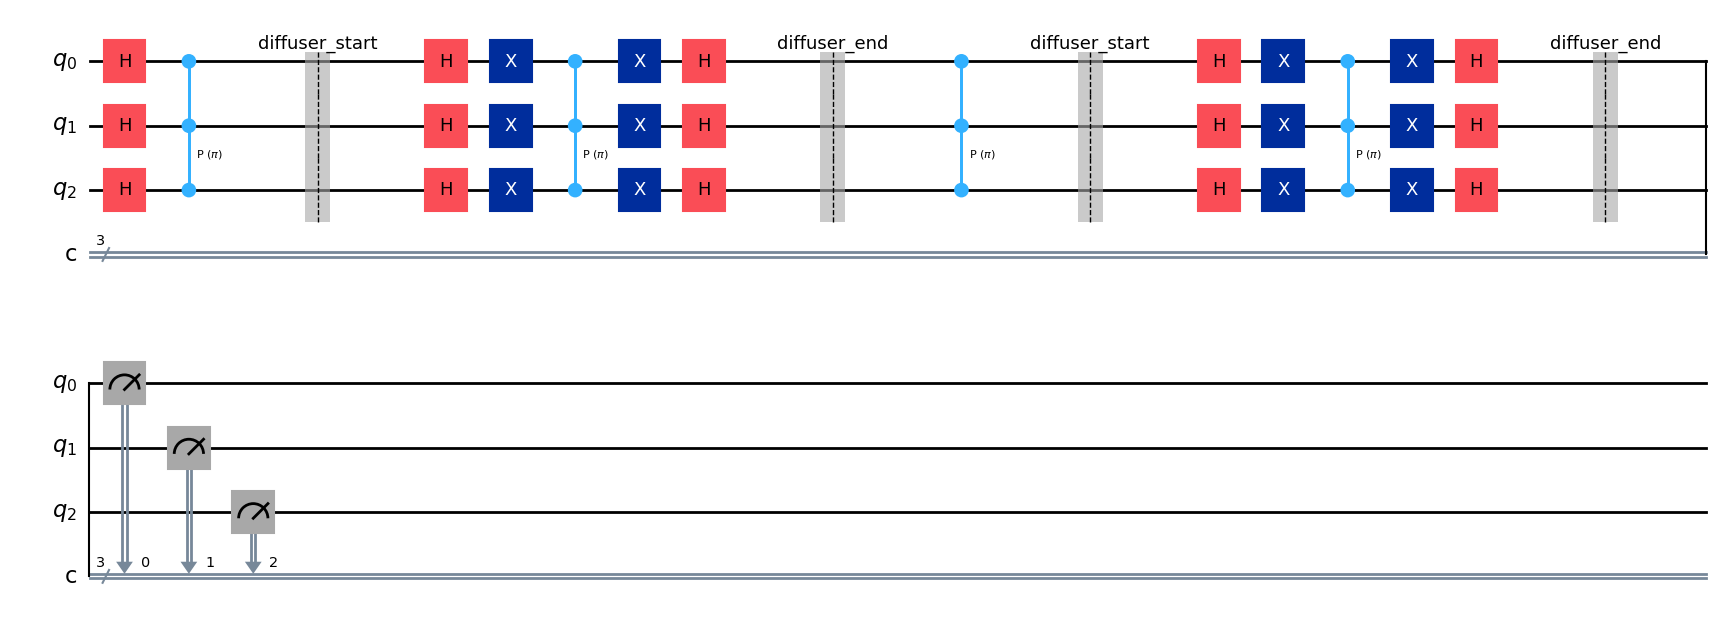

In [37]:
num_qubits = 3

def basic_all_ones_oracle(qc: QuantumCircuit, qbits: int):
    """
    A basic oracle that marks the state |11...1> by shifting its phase by pi.
    """
    control = list(range(qbits - 1))
    target = qbits - 1
    qc.mcp(np.pi, control, target)


grover = GroverAlgorithm(num_qubits=num_qubits, oracle_function=basic_all_ones_oracle)
grover_circuit = grover.build_circuit()

grover_circuit.draw(output="mpl")

Measurement outcomes: {'110': 8, '010': 5, '000': 5, '101': 6, '001': 8, '100': 7, '011': 6, '111': 979}


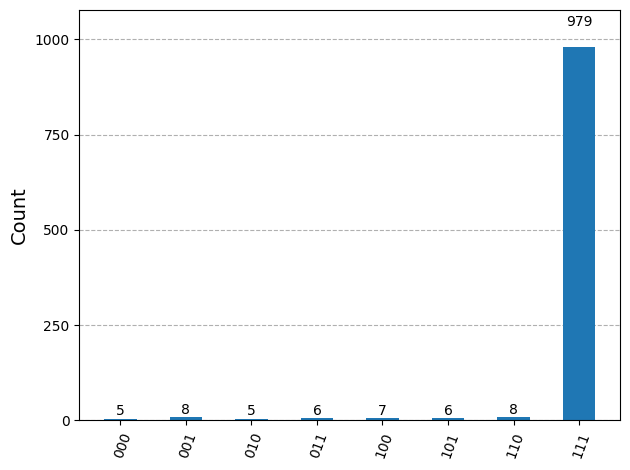

In [38]:
# Simulate the constructed Grover circuit
simulator = AerSimulator()
job = simulator.run(grover_circuit, shots=1024)
result = job.result()

# Get measurement counts and print them
counts = result.get_counts(grover_circuit)
print(f"Measurement outcomes: {counts}")

# Plot the histogram of measurement outcomes
plot_histogram(counts)